In [3]:
import numpy as np
import time
import sys
import math

import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

import bluequbit

import qiskit.qasm2

In [4]:
#pip install Quimb

In [5]:
q = qiskit.qasm2.load("P4_golden_mountain.qasm")

In [6]:
len(q.data)

15384

In [431]:
cut_start = 7000
cut_number = 2048

qc_cut = QuantumCircuit(48,48)
for q_i in range(cut_start, cut_start + cut_number):
    qc_cut.append(q.data[q_i], qc_cut.qubits, qc_cut.clbits)

qc_cut.draw('mpl')

In [272]:
def check_how_many_cz(qc, qbit_num_1):
    qc_len = len(qc.data)
    gate_num_list = []
    for i in range(qc_len):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if the gate involves both the qubits we want to check
        if qubits_number > 1:
            if (q_list[0] == qbit_num_1) or (q_list[1] == qbit_num_1):
                gate_num_list.append(i)
    return gate_num_list

In [273]:
for i in range(48):
    print(len(check_how_many_cz(q, i)))

212
212
212
212
213
213
212
213
213
212
212
210
210
212
212
212
212
212
212
212
212
212
212
212
212
213
213
214
214
212
212
213
213
213
214
213
213
213
212
212
212
213
213
212
212
212
212
212


In [274]:
def check_how_many_cz(qc, qbit_num_1, qbit_num_2):
    qc_len = len(qc.data)
    gate_num_list = []
    for i in range(qc_len):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if the gate involves both the qubits we want to check
        if qubits_number > 1:
            if (q_list[0] == qbit_num_1 and q_list[1] == qbit_num_2) or (q_list[0] == qbit_num_2 and q_list[1] == qbit_num_1):
                gate_num_list.append(i)
    return gate_num_list

In [44]:
coupling_map = np.zeros((48, 48))

cut_start = 0
cut_number = 7200

qc_cut = QuantumCircuit(48,48)
for q_i in range(15384):
    qc_cut.append(q.data[q_i], qc_cut.qubits, qc_cut.clbits)

for iq_1 in range(48):
    for iq_2 in range(0, 48):
        coupling_map[iq_1][iq_2] = len(check_how_many_cz(q, iq_1, iq_2))
 

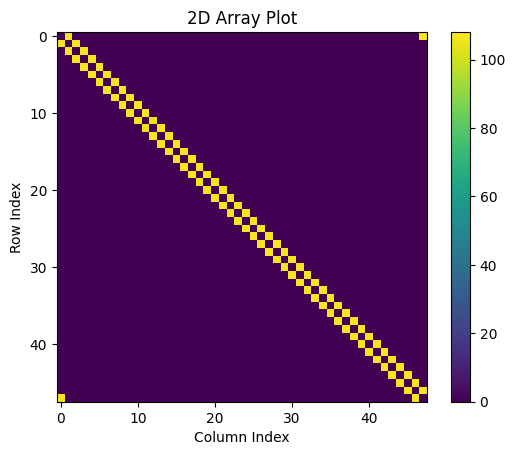

In [45]:
plt.imshow(coupling_map, cmap='viridis')  # Use a colormap for visualization
plt.colorbar()  # Add a colorbar to show value mapping
plt.title('2D Array Plot')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

In [21]:
bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
result = bq.run(q, device='quantum', shots = 1000)

[BQ-PYTHON-SDK][WARNING] - Beta version 0.12.0b1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: c0t2BCrGKkij4UWM, device: quantum, run status: PENDING, created on: 2025-04-12 18:09:42 UTC, estimated runtime: 1 ms, estimated cost: $1.20, num qubits: 48


In [279]:
counts = result.get_counts()


In [280]:
print(result.get_counts())

{'0000': 1117, '0001': 387, '0010': 1014, '0011': 482}


In [25]:
from qiskit.visualization import plot_histogram
#counts = result.get_counts()
plot_histogram(counts, title = 'results')

AttributeError: 'NoneType' object has no attribute 'values'

In [5]:
#the function finds the last gate using qubit qbit_num in circuit qc
def last_gate(qc, qbit_num):
    qubit_last_gate = -1
    qc_len = len(qc.data)
    for i in range(qc_len - 1, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        found = 0
        for i_q in range(qubits_number):
            if cur_gate[1][i_q]._index == qbit_num:
                qubit_last_gate = i
                found = 1
        if found == 1:
            break
    return qubit_last_gate

In [6]:
def light_cone(qc, qbit_num):
    start_point = last_gate(qc, qbit_num)
    qc_len = len(qc.data)
    cone_list = []
    cone_list.append(qbit_num)
    for i in range(start_point, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if qubits particiapating in the gate are in the list of the light cone or not
        if qubits_number > 1:
            if (q_list[0] in cone_list) and (q_list[1] not in cone_list):
                cone_list.append(q_list[1])
            if (q_list[1] in cone_list) and (q_list[0] not in cone_list):
                cone_list.append(q_list[0])
    return cone_list, len(cone_list)

In [14]:
for i in range(48):
    ff,aa = light_cone(q, i)
    print(aa)

48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48


In [15]:
#the function finds the last gate using qubit qbit_num in circuit qc
def last_cz_gate(qc, qbit_num):
    qubit_last_gate = -1
    qc_len = len(qc.data)
    for i in range(qc_len - 1, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        found = 0
        for i_q in range(qubits_number):
            if (cur_gate[1][i_q]._index) == qbit_num and (cur_gate[0].name == 'cz'):
                qubit_last_gate = i
                found = 1
        if found == 1:
            break
    return qubit_last_gate
    

In [53]:
def check_is_there_identical_z(qc, qbit_num_1):
    qc_len = len(qc.data)
    angles_list = []
    num_id_angles = 0
    n_z = 0
    id_angles_list = []
    for i in range(qc_len):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        if (cur_gate[0].name == 'u3'):
            n_z = n_z + 1
            cur_angle_1 = cur_gate[0].params[0]
            cur_angle_2 = cur_gate[0].params[1]
            cur_angle_3 = cur_gate[0].params[2]
            if (cur_angle_3 in angles_list):
                num_id_angles = num_id_angles + 1
            else:
                angles_list.append(cur_angle_1)
                
    return num_id_angles, id_angles_list, n_z

In [54]:
check_is_there_identical_z(q, 0)

(2057, [], 10240)

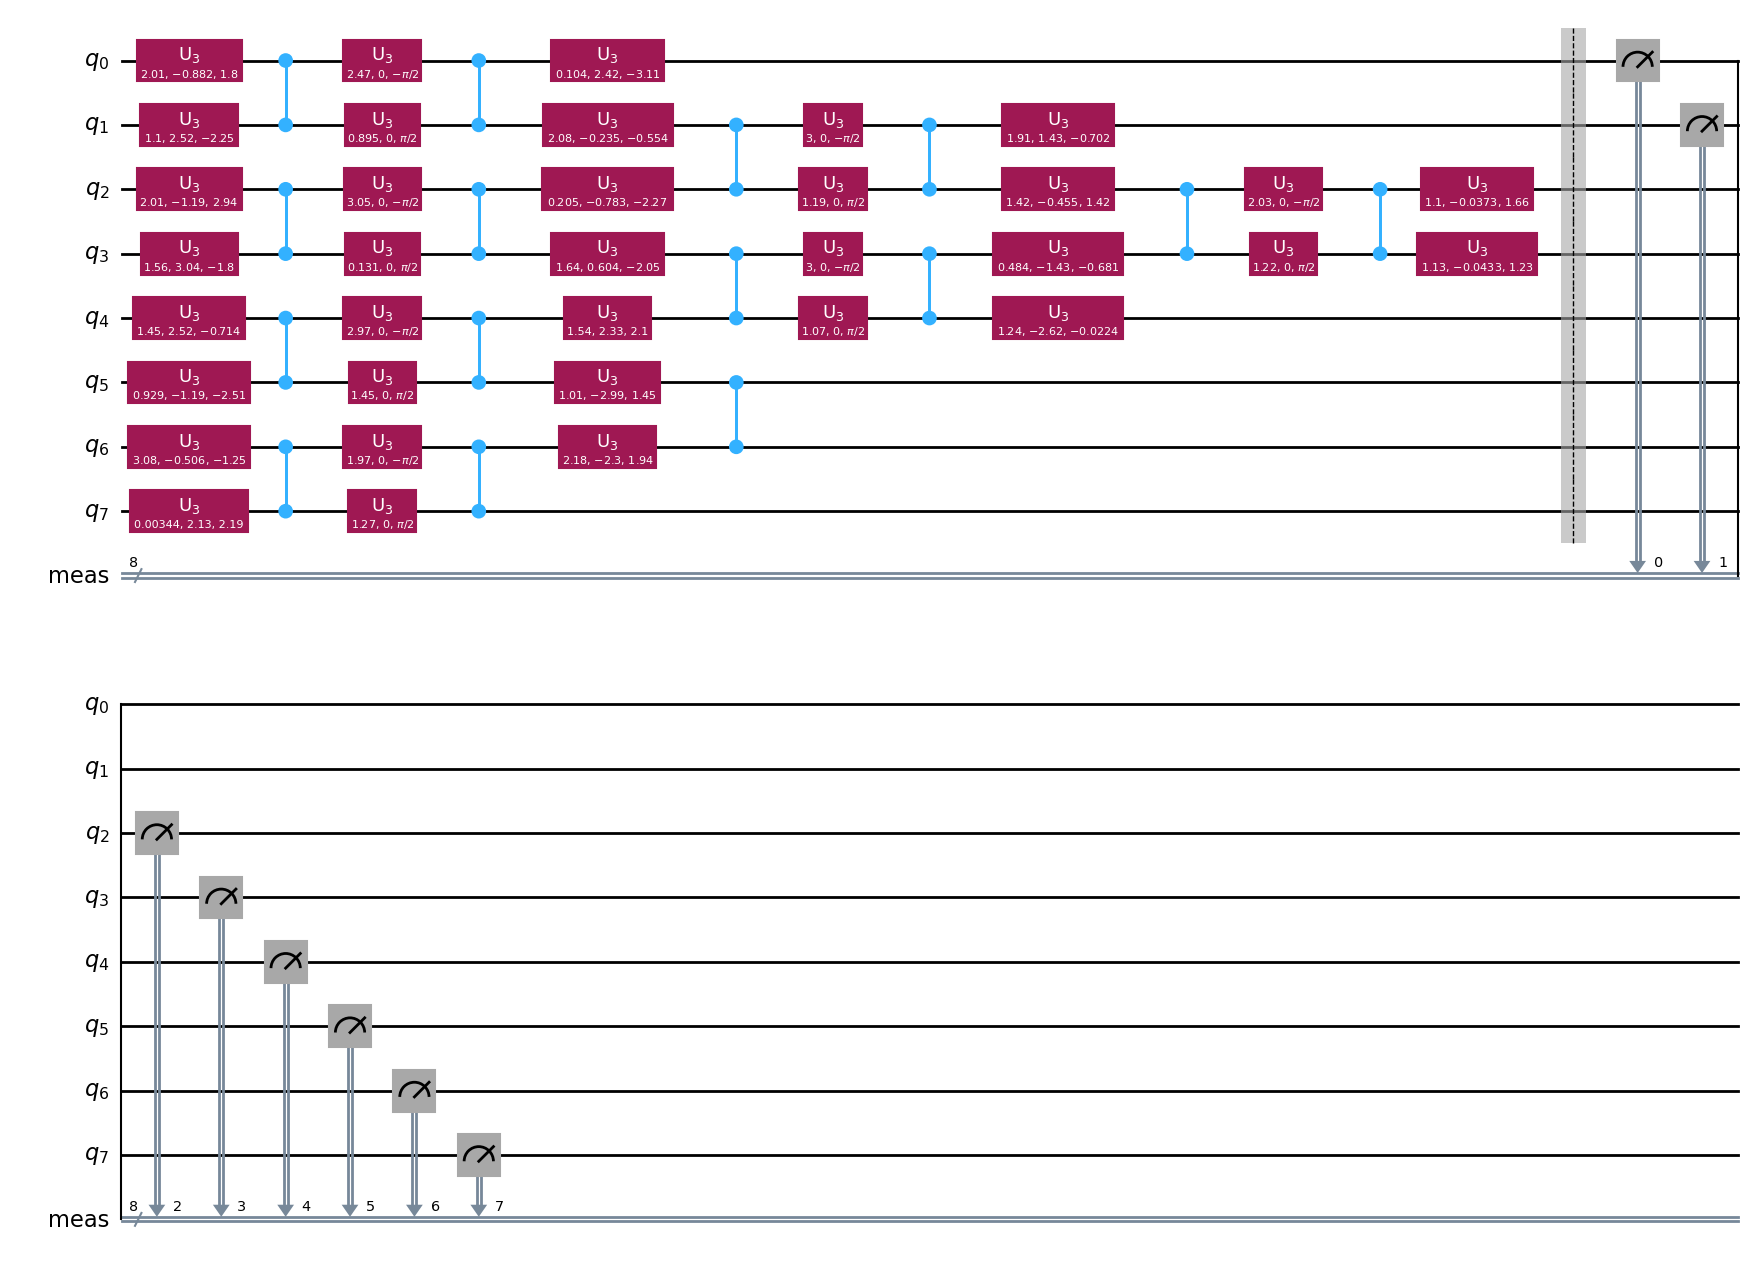

In [427]:
cut_start = 0
cut_number = 50
q_list = [0, 1,2,3, 4,5,6,7]
qc_cut = QuantumCircuit(8)
cz_count = 0
for q_i in range(cut_start, cut_start + cut_number):
    cur_gate = q.data[q_i] 
    if cur_gate[0].name == 'u3':
        cur_angle_1 = cur_gate[0].params[0]
        cur_angle_2 = cur_gate[0].params[1]
        cur_angle_3 = cur_gate[0].params[2]
        curr_q = cur_gate[1][0]._index
        if curr_q in q_list:
            new_ind = q_list.index(curr_q)
            gate = qiskit.circuit.library.U3Gate(cur_angle_1, cur_angle_2,cur_angle_3)
            qc_cut.append(gate, [new_ind])
    if cur_gate[0].name == 'cz':
        curr_q_1 = cur_gate[1][0]._index
        curr_q_2 = cur_gate[1][1]._index
        if (curr_q_1 in q_list) and (curr_q_2 in q_list):
            new_ind_1 = q_list.index(curr_q_1)
            new_ind_2 = q_list.index(curr_q_2)
            gate = qiskit.circuit.library.CZGate()
            cz_count = cz_count + 1
            if cz_count not in [0]:
                qc_cut.append(gate, [new_ind_1, new_ind_2])
            
qc_cut.measure_all()

qc_cut.draw('mpl')


In [428]:
bq = bluequbit.init("ifvQUoJTa445RywgR6thzt5D2dCtAezL")
result = bq.run(qc_cut, device='cpu', shots = 3000)


[BQ-PYTHON-SDK][WARNING] - Beta version 0.12.0b1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: PYfbTd1JKfu3JYcP, device: cpu, run status: COMPLETED, created on: 2025-04-13 02:03:59 UTC, cost: $0.00, run time: 19 ms, queue time: 70 ms, num qubits: 8


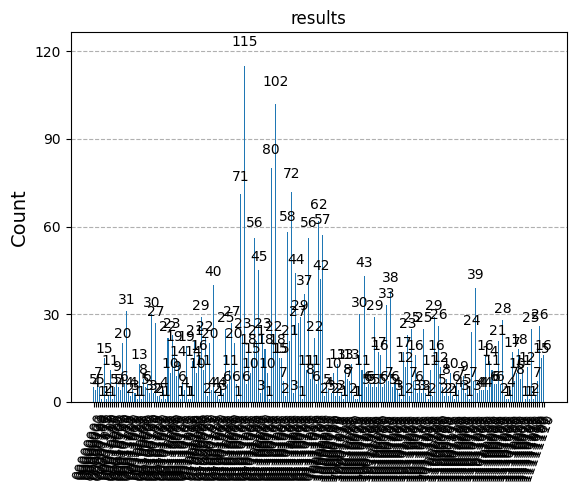

In [429]:
from qiskit.visualization import plot_histogram
counts = result.get_counts()
plot_histogram(counts, title = 'results')

In [159]:
options = {
    "mps_bond_dimension": 2,
}
result = bq.run(qc_cut, device="mps.cpu", options=options) # should take ~30seconds

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: wlpUzvqpthxfBcJ7, device: mps.cpu, run status: RUNNING, created on: 2025-04-12 21:54:32 UTC, estimated runtime: 100 ms, estimated cost: $0.00, num qubits: 4


In [160]:
counts = result.get_counts()
counts

{'0000': 103,
 '0001': 80,
 '0011': 135,
 '0100': 49,
 '0101': 42,
 '0110': 4,
 '0111': 117,
 '1000': 91,
 '1001': 132,
 '1010': 89,
 '1100': 47,
 '1101': 84,
 '1110': 51}

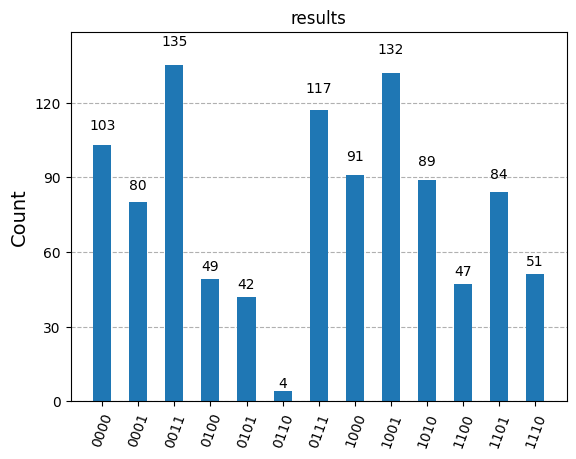

In [161]:
#from qiskit.visualization import plot_histogram
#counts = result.get_counts()
plot_histogram(counts, title = 'results')

In [157]:
for dic in counts:
    if counts[dic] > 1:
        ans1 = dic


In [131]:
print(ans1)
print(counts[ans1])

NameError: name 'ans1' is not defined

In [232]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from IPython.display import display

def operator_an_2(qc, q_1):
    qc_len = len(qc.data)
    qc_loc = QuantumCircuit(2)
    counter = 0
    cur_gate = qc.data[7890]
    curr_q = cur_gate[1][0]._index
    cur_angle_1 = cur_gate[0].params[0]
    cur_angle_2 = cur_gate[0].params[1]
    cur_angle_3 = cur_gate[0].params[2]
    gate = qiskit.circuit.library.U3Gate(cur_angle_1, cur_angle_2,cur_angle_3)
    com_op = Operator(gate)
    
    for i in range(0, 15000):
        cur_gate = qc.data[i]
        if (cur_gate[0].name == 'u3'):
            curr_q = cur_gate[1][0]._index
            cur_angle_1 = cur_gate[0].params[0]
            cur_angle_2 = cur_gate[0].params[1]
            cur_angle_3 = cur_gate[0].params[2]
            gate = qiskit.circuit.library.U3Gate(cur_angle_1, cur_angle_2,cur_angle_3)
            op = Operator(gate)
            #display(array_to_latex(op, precision=1))
            if (op == com_op):
                print('w')
    return 0

In [233]:
operator_an_2(q, 7)

w


0